In [1]:
import os
import gdown
import zipfile

file_id = "1EuSO2gnQ0GYX3qCUazgAjQEaSyYrt8w4"

output_file = "file.zip"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, output_file, quiet=False)

if os.path.exists(output_file):
    with zipfile.ZipFile(output_file, 'r') as zip_ref:
        zip_ref.extractall("extracted_files")
    print("Extraction completed!")
else:
    print("Download failed or file does not exist.")

Downloading...
From: https://drive.google.com/uc?id=1EuSO2gnQ0GYX3qCUazgAjQEaSyYrt8w4
To: /content/file.zip
100%|██████████| 12.6M/12.6M [00:00<00:00, 129MB/s]


Extraction completed!


In [2]:
!pip install datasets iterative-stratification

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [3]:
import os
import pandas as pd

train_folder_path = "/content/extracted_files/public_data_test/track_a/train"
dev_folder_path = "/content/extracted_files/public_data_test/track_a/dev"

def load_and_process_folder(folder_path):
    dataframes = []
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)
            df.columns = [col.lower() for col in df.columns]
            sampled_df = df.sample(frac=0.15, random_state=42)
            dataframes.append(sampled_df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    if len(combined_df.columns) >= 6:
        for col in combined_df.columns[-6:]:
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce').fillna(0).astype(int)
    return combined_df

df_train = load_and_process_folder(train_folder_path)
df_test = load_and_process_folder(dev_folder_path)

df = pd.concat([df_train, df_test], ignore_index=True)

In [4]:
df_train

,id,text,anger,disgust,fear,joy,sadness,surprise
0,hau_train_track_a_01345,Wata sabuwa. Maaga wannan Almaraa.🙄🤔🤔,0,0,0,0,0,1
1,hau_train_track_a_01935,AMINTACCIYAR JARIDARKU ta wannan mako,0,0,0,0,0,0
2,hau_train_track_a_00129,Jonathan ya fusata saboda rashin daukar nauyin...,1,0,0,0,0,0
3,hau_train_track_a_00333,Subhanallah ya Allah ka kawo mana karshen wada...,0,0,1,0,1,0
4,hau_train_track_a_01164,Haramta Shan Barasa a Qatar Na Taimakawa Mata ...,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
9758,orm_train_track_a_02275,Gammmeee jabaaadhu waaan gaaariii hojjjechaaa ...,0,0,0,1,0,0
9759,orm_train_track_a_02716,Baga geessan ilmaan oromoo hundi keessan Wagga...,0,0,0,1,0,0
9760,orm_train_track_a_00434,Ilmmma saba miiidhamaaa oromooo Siraj sabaaaf ...,0,0,0,1,0,0
9761,orm_train_track_a_02476,Hayyuu koo dukkana booda ifaatu jira hin yaadi...,0,0,0,0,1,0


In [5]:
df_test

,id,text,anger,disgust,fear,joy,sadness,surprise
0,hau_dev_track_a_00228,Tashin Hankali Yayin da Mahara Suka Yi Garkuwa...,0,0,1,0,0,0
1,hau_dev_track_a_00043,ke zakiyi aurene,0,0,0,0,0,1
2,hau_dev_track_a_00257,"""Ba a Kyauta Mana"": Soja Ya Fusata Kan Kyautar...",1,0,0,0,0,0
3,hau_dev_track_a_00183,Cigaba: Mota mai tashi ta kammala shawagin gwa...,0,0,0,0,0,0
4,hau_dev_track_a_00057,Yan maiduguri suna taya kowa murnan shigowa sy...,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...
1272,orm_dev_track_a_00185,Yoooyyyaaa caaaltiyyyeee esssaaa dhufteee ...,0,0,0,1,0,0
1273,orm_dev_track_a_00087,Waaan na jajjjabesaaa jirtanif galllataaa gu...,0,0,0,1,0,0
1274,orm_dev_track_a_00232,Raaabiii siiin kabajiiin kabajaaa maaaliii bee...,0,1,0,0,0,0
1275,orm_dev_track_a_00209,Koronaavaayiras: Hidha Haaromsaa Itoophiyaafi ...,0,0,1,0,0,0


In [6]:
ID2LABEL = {}
LABEL2ID = {}

for idx,label in enumerate(df_train.columns):
    if label in ['text'] or label in ['id']:
        continue

    ID2LABEL[idx-1] = label
    LABEL2ID[label] = idx-1

print(f"ID2LABEL: {ID2LABEL}")
print(f"LABEL2ID: {LABEL2ID}")

ID2LABEL: {1: 'anger', 2: 'disgust', 3: 'fear', 4: 'joy', 5: 'sadness', 6: 'surprise'}
LABEL2ID: {'anger': 1, 'disgust': 2, 'fear': 3, 'joy': 4, 'sadness': 5, 'surprise': 6}


In [7]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# X = df['text']
# y = df.drop('text', axis=1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

label_columns = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

# Features and labels
X = df.drop(label_columns, axis=1)
y = df[label_columns]

# Initialize stratifier
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform stratified split
for train_idx, test_idx in msss.split(X, y):
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

dataset_dict = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

# Print information about the DatasetDict
print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise'],
        num_rows: 8832
    })
    test: Dataset({
        features: ['id', 'text', 'anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise'],
        num_rows: 2208
    })
})


In [8]:
# get emotion counts by split type
split_types = list(dataset_dict.keys())
emotion_split_counts = {}

for label in LABEL2ID:
    for split_type in split_types:
        if label not in emotion_split_counts:
            emotion_split_counts[label] = []
        emotion_split_counts[label].append(sum(dataset_dict[split_type][label]))

print(f"SPLIT_TYPES: {split_types}")
print(f"EMOTION_SPLIT_COUNTS: {emotion_split_counts}")

SPLIT_TYPES: ['train', 'test']
EMOTION_SPLIT_COUNTS: {'anger': [1556, 389], 'disgust': [1483, 371], 'fear': [909, 227], 'joy': [1785, 446], 'sadness': [1638, 409], 'surprise': [1009, 252]}


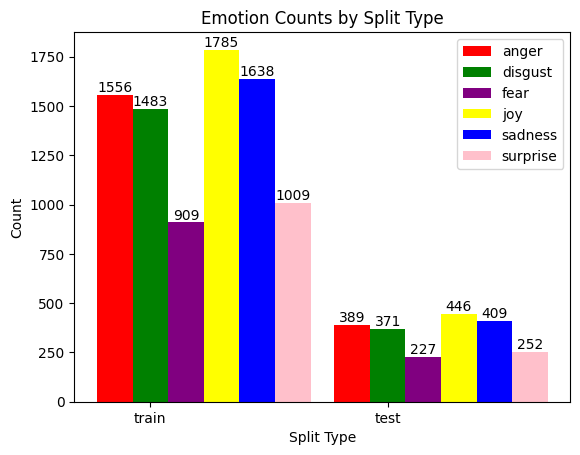

In [9]:
import matplotlib.pyplot as plt
import numpy as np

LABEL2COLOR = {
    'anger': 'red',
    'disgust': 'green',
    'fear':'purple',
    'joy': 'yellow',
    'sadness': 'blue',
    'surprise': 'pink',
}

x = np.arange(len(split_types))
width = 0.15
multiplier = 0

fig, ax = plt.subplots()
for label, counts in emotion_split_counts.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=label, color=LABEL2COLOR[label])
    ax.bar_label(rects, label_type='edge')
    multiplier += 1

ax.set_xlabel('Split Type')
ax.set_ylabel('Count')
ax.set_title('Emotion Counts by Split Type')
ax.set_xticks(x + width, split_types)
ax.legend()
plt.show()

In [10]:
emotion_counts = {}
for label in LABEL2ID:
    for split_type in dataset_dict.keys():
        emotion_counts[label] = emotion_counts.get(label,0)+sum(dataset_dict[split_type][label])

print(f"EMOTION_COUNTS: {emotion_counts}")

EMOTION_COUNTS: {'anger': 1945, 'disgust': 1854, 'fear': 1136, 'joy': 2231, 'sadness': 2047, 'surprise': 1261}


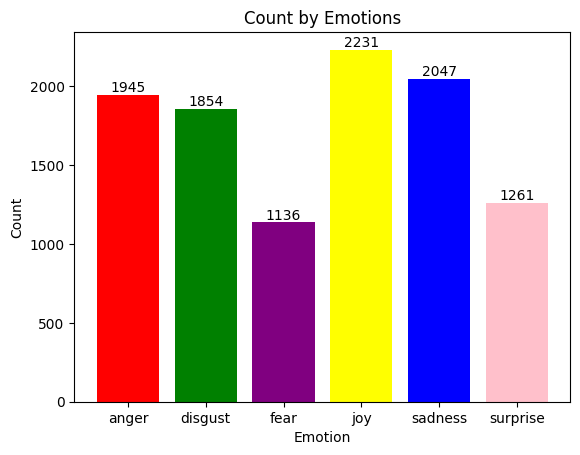

In [11]:
# plot bar graph with total emotion counts
fig, ax = plt.subplots()
bar_container = ax.bar(emotion_counts.keys(), emotion_counts.values(), color=LABEL2COLOR.values())
ax.bar_label(bar_container, label_type='edge')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.set_title('Count by Emotions')
plt.show()

# Preprocessing

In [12]:
def preprocess(batch):
    # rename column
    # batch['ID'] = batch['id']
    batch['Text'] = batch['text']

    # get one-hot encoded labels for each example in batch
    # for example: anger and sadness = vector of [1,0,0,0,1]
    batch['labels'] = [[float(batch[label][i]) for label in LABEL2ID] for i in range(len(batch['text']))]
    return batch

preprocessed_datasets = dataset_dict.map(preprocess, batched=True, remove_columns=dataset_dict['train'].column_names)
preprocessed_datasets

Map:   0%|          | 0/8832 [00:00<?, ? examples/s]

Map:   0%|          | 0/2208 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Text', 'labels'],
        num_rows: 8832
    })
    test: Dataset({
        features: ['Text', 'labels'],
        num_rows: 2208
    })
})

In [13]:
preprocessed_datasets['train'][2]

{'Text': "Subhanallah ya Allah ka kawo mana karshen wadannan masifu,Astaghfirullah wa'atubu ilaik🤲",
 'labels': [0.0, 0.0, 1.0, 0.0, 1.0, 0.0]}

# Data Tokenization

In [14]:
from transformers import AutoTokenizer

CHECKPOINT = 'FacebookAI/xlm-roberta-base' #change this
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
tokenizer

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

XLMRobertaTokenizerFast(name_or_path='FacebookAI/xlm-roberta-base', vocab_size=250002, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	250001: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}
)

In [15]:
# tokenize out datasets with truncation
tokenized_datasets = preprocessed_datasets.map(lambda batch: tokenizer(batch['Text'], padding="max_length", truncation=True, max_length=512), batched=True, remove_columns=['Text'])
tokenized_datasets

Map:   0%|          | 0/8832 [00:00<?, ? examples/s]

Map:   0%|          | 0/2208 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 8832
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2208
    })
})

In [16]:
tokenized_datasets['train'][:1]

{'labels': [[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]],
 'input_ids': [[0,
   6586,
   11,
   29033,
   47154,
   5,
   16923,
   208,
   18918,
   43881,
   219,
   11,
   5,
   244028,
   243691,
   243691,
   2,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1

# Model Training

In [17]:
# set seed for reproducibility
import torch

SEED = 42
torch.manual_seed(SEED)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [19]:
# let's clone a model and finetune as a multi-label classification problem
from transformers import AutoModelForSequenceClassification

# source: https://huggingface.co/FacebookAI/xlm-roberta-base
model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, problem_type='multi_label_classification', num_labels=len(LABEL2ID), id2label=ID2LABEL, label2id=LABEL2ID)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# this function calculates accuracy per label in a prediction instead of per prediction
def samples_accuracy_score(y_true, y_pred):
    return np.sum(y_true==y_pred) / y_true.size

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    # we sigmoid all logits for multilabel metrics
    predictions = torch.nn.functional.sigmoid(torch.Tensor(logits))
    # we set threshold to 0.50 to classify positive >= 0.50 and negative < 0.50
    predictions = (predictions >= 0.50).int().numpy()
    # overall accuracy measures accuracy of each true label list and prediction list
    overall_accuracy = accuracy_score(labels, predictions)
    # sample accuracy measures accuracy of each true label in a true label list and prediction in prediction list
    samples_accuracy = samples_accuracy_score(labels, predictions)
    # overall f1 measures macro f1 of each true label list and prediction list, ignoring zero division warnings
    overall_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    # samples f1 measures f1 of each true label in a true label list and prediction in prediction list, ignoring zero division warnings
    samples_f1 = f1_score(labels, predictions, average='samples', zero_division=0)
    return {
        'overall_accuracy': overall_accuracy,
        'samples_accuracy': samples_accuracy,
        'overall_f1': overall_f1,
        'samples_f1': samples_f1,
    }

In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    seed=SEED,                          # seed for reproducibility
    output_dir='results',               # output directory to store epoch checkpoints
    num_train_epochs=5,                 # number of training epochs
    optim='adamw_torch',                # default optimizer as AdamW
    per_device_train_batch_size=32,     # 32 train batch size to speed up training
    per_device_eval_batch_size=32,      # 32 eval batch size to speed up evaluation
    evaluation_strategy='epoch',        # set evaluation strategy to each epoch instead of default 500 steps
    save_strategy='epoch',              # set saving of model strategy to each epoch instead of default 500 steps
    load_best_model_at_end=True,        # load the best model with lowest validation loss
    report_to='none',                   # suppress third-party logging
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [22]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

<ipython-input-22-878777cbfc94>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [23]:
# let's see what an unfine-tuned model can do
trainer.evaluate(tokenized_datasets['test'])

{'eval_loss': 0.6938365697860718,
 'eval_model_preparation_time': 0.0083,
 'eval_overall_accuracy': 0.0022644927536231885,
 'eval_samples_accuracy': 0.48211050724637683,
 'eval_overall_f1': 0.15172869449679452,
 'eval_samples_f1': 0.20681504485852312,
 'eval_runtime': 59.0421,
 'eval_samples_per_second': 37.397,
 'eval_steps_per_second': 1.169}

In [24]:
# let's fine-tune the model as a multilabel problem
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Overall Accuracy,Samples Accuracy,Overall F1,Samples F1
1,No log,0.407198,0.008300,0.259964,0.840127,0.040307,0.022222
2,0.420600,0.380474,0.008300,0.310688,0.851223,0.250223,0.138647
3,0.420600,0.361055,0.008300,0.360054,0.859526,0.332290,0.194104
4,0.360700,0.350791,0.008300,0.381341,0.863149,0.375761,0.218176
5,0.360700,0.346080,0.008300,0.390851,0.863527,0.428583,0.259118


TrainOutput(global_step=1380, training_loss=0.3697586501854053, metrics={'train_runtime': 5122.9376, 'train_samples_per_second': 8.62, 'train_steps_per_second': 0.269, 'total_flos': 1.161940149338112e+16, 'train_loss': 0.3697586501854053, 'epoch': 5.0})

In [25]:
# let's see what a finetuned model can do
trainer.evaluate(tokenized_datasets['test'])

{'eval_loss': 0.34607982635498047,
 'eval_model_preparation_time': 0.0083,
 'eval_overall_accuracy': 0.3908514492753623,
 'eval_samples_accuracy': 0.8635265700483091,
 'eval_overall_f1': 0.4285826391945496,
 'eval_samples_f1': 0.2591183574879227,
 'eval_runtime': 60.33,
 'eval_samples_per_second': 36.599,
 'eval_steps_per_second': 1.144,
 'epoch': 5.0}

In [26]:
predictions, label_ids, metrics = trainer.predict(tokenized_datasets['test'])

In [27]:
sigmoid = torch.sigmoid(torch.tensor(predictions))

In [28]:
predicted_labels = sigmoid.numpy()

In [29]:
threshold = 0.5
predicted_labels_binary = (predicted_labels > threshold).astype(int)

In [30]:
for idx, (pred, true_label) in enumerate(zip(predicted_labels_binary, label_ids)):
    print(f"Row {idx}: Predicted labels = {pred}, True labels = {true_label}")

Row 0: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 0. 0. 0. 0.]
Row 1: Predicted labels = [0 0 0 0 1 0], True labels = [0. 0. 1. 0. 1. 0.]
Row 2: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 0. 1. 0. 0.]
Row 3: Predicted labels = [0 0 0 0 0 0], True labels = [1. 0. 0. 0. 0. 0.]
Row 4: Predicted labels = [0 0 0 0 1 0], True labels = [0. 1. 1. 0. 0. 0.]
Row 5: Predicted labels = [0 0 0 0 0 0], True labels = [0. 1. 0. 0. 0. 0.]
Row 6: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 0. 1. 0. 0.]
Row 7: Predicted labels = [0 0 0 1 0 0], True labels = [0. 0. 0. 0. 0. 1.]
Row 8: Predicted labels = [0 0 0 0 1 0], True labels = [1. 0. 0. 0. 1. 0.]
Row 9: Predicted labels = [0 0 0 0 0 0], True labels = [0. 1. 0. 0. 1. 1.]
Row 10: Predicted labels = [0 0 0 0 0 0], True labels = [1. 0. 0. 0. 1. 0.]
Row 11: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 0. 0. 0. 0.]
Row 12: Predicted labels = [0 0 0 0 0 0], True labels = [1. 0. 0. 0. 0. 0.]
Row 13: Predicted labe

# Saving model


In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
model_name = "model-FacebookAI_xlm-roberta-base" #change this mf
trainer.save_model(model_name)

In [33]:
import shutil
import os

shutil.make_archive(model_name, 'zip', model_name)

'/content/model-FacebookAI_xlm-roberta-base.zip'

# predict dataset

In [ ]:
# file_id = "1CWputWVBLKxj4zqmYihisTNVPQexID1b" #model link

# output_file = "model.zip"

# url = f"https://drive.google.com/uc?id={file_id}"

# gdown.download(url, output_file, quiet=False)

# if os.path.exists(output_file):
#     with zipfile.ZipFile(output_file, 'r') as zip_ref:
#         zip_ref.extractall("model")
#     print("Extraction completed!")
# else:
#     print("Download failed or file does not exist.")

Downloading...
From (original): https://drive.google.com/uc?id=1CWputWVBLKxj4zqmYihisTNVPQexID1b
From (redirected): https://drive.google.com/uc?id=1CWputWVBLKxj4zqmYihisTNVPQexID1b&confirm=t&uuid=020162ca-0b57-41ad-9d49-a191431f1bd5
To: /content/model.zip
100%|██████████| 823M/823M [00:18<00:00, 44.6MB/s]


Extraction completed!


In [34]:
from transformers import pipeline
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch
import os
import pandas as pd

SEED = 42
torch.manual_seed(SEED)

CHECKPOINT = model_name
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.config.label2id = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'joy': 3,
    'sadness': 4,
    'surprise': 5
}
model.config.id2label = {v: k for k, v in model.config.label2id.items()}
finetuned = pipeline(
    task='text-classification',
    model=model,
    tokenizer=tokenizer,
    device=torch.cuda.current_device(),
    top_k=None,
    truncation=True,
    max_length=512
)

Device set to use cuda:0


In [35]:
from tqdm import tqdm

emotion_labels = ['anger','disgust','fear','joy','sadness','surprise']

def classify_emotions(text):
    truncated_text = text[:512]
    results = finetuned(truncated_text)
    threshold = 0.5
    binary_labels = {em: 0 for em in emotion_labels}
    for pred in results[0]:
        lbl, score = pred['label'].lower(), pred['score']
        if lbl in binary_labels and score > threshold:
            binary_labels[lbl] = 1
    return [binary_labels[em] for em in emotion_labels]

folder_path = "/content/extracted_files/public_data_test/track_a/dev"
output_dir = "/content/pred_report/pred"
os.makedirs(output_dir, exist_ok=True)

for csv_file in tqdm(os.listdir(folder_path), desc="Processing CSV files"):
    if csv_file.endswith(".csv"):
        file_path = os.path.join(folder_path, csv_file)
        df = pd.read_csv(file_path)

        # Apply classification
        df[emotion_labels] = pd.DataFrame(
            df['text'].apply(classify_emotions).to_list(),
            index=df.index
        )

        out_name = os.path.join(output_dir, f"{os.path.splitext(csv_file)[0]}_pred.csv")
        df.to_csv(out_name, index=False)

Processing CSV files: 100%|██████████| 28/28 [01:20<00:00,  2.87s/it]


In [36]:
def evaluate_predictions(folder_path, pred_dir):
    print("\n=== Phase 2: Evaluation ===")
    for csv_file in tqdm(os.listdir(folder_path), desc="Evaluating CSV files"):
        if csv_file.endswith(".csv"):
            print(f"\nEvaluating {csv_file}...")
            original_file_path = os.path.join(folder_path, csv_file)
            predicted_file_path = os.path.join(pred_dir, f"{os.path.splitext(csv_file)[0]}_pred.csv")

            if not os.path.exists(predicted_file_path):
                print(f"Predicted file {predicted_file_path} not found. Skipping evaluation for {csv_file}.")
                continue

            df_original = pd.read_csv(original_file_path)
            df_predicted = pd.read_csv(predicted_file_path)

            # Extract the list of emotion labels
            emotions = ['Anger', 'Disgust', 'Fear', 'Joy', 'Sadness', 'Surprise']
            emotions = df_original.columns[2:]

            # Ensure emotion labels are lowercase to match prediction columns
            emotions = [em.lower() for em in emotions]

            # Calculate precision, recall, and F1 for each emotion (macro)
            precision_scores = precision_score(df_original[emotions], df_predicted[emotions], average=None)
            recall_scores = recall_score(df_original[emotions], df_predicted[emotions], average=None)
            f1_scores = f1_score(df_original[emotions], df_predicted[emotions], average=None)

            # Calculate macro and micro averages
            macro_precision = precision_score(df_original[emotions], df_predicted[emotions], average='macro', zero_division=0)
            macro_recall = recall_score(df_original[emotions], df_predicted[emotions], average='macro', zero_division=0)
            macro_f1 = f1_score(df_original[emotions], df_predicted[emotions], average='macro', zero_division=0)

            micro_precision = precision_score(df_original[emotions], df_predicted[emotions], average='micro', zero_division=0)
            micro_recall = recall_score(df_original[emotions], df_predicted[emotions], average='micro', zero_division=0)
            micro_f1 = f1_score(df_original[emotions], df_predicted[emotions], average='micro', zero_division=0)

            # Generate & save report
            dict_pred = {
                'lang': os.path.splitext(csv_file)[0],
                'macro_precision': macro_precision,
                'macro_recall': macro_recall,
                'macro_f1': macro_f1,
                'micro_precision': micro_precision,
                'micro_recall': micro_recall,
                'micro_f1': micro_f1
            }
            report_name = f"./pred_report/report/report_{os.path.splitext(csv_file)[0]}.csv"
            os.makedirs(os.path.dirname(report_name), exist_ok=True)
            pd.DataFrame([dict_pred]).to_csv(report_name, index=False)
            print(f"Saved evaluation report to {report_name}.")

In [37]:
evaluate_predictions(folder_path, output_dir)


=== Phase 2: Evaluation ===


Evaluating CSV files:   7%|▋         | 2/28 [00:00<00:01, 18.36it/s]


Evaluating hau.csv...
Saved evaluation report to ./pred_report/report/report_hau.csv.

Evaluating som.csv...
Saved evaluation report to ./pred_report/report/report_som.csv.

Evaluating ron.csv...
Saved evaluation report to ./pred_report/report/report_ron.csv.

Evaluating afr.csv...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Evaluating CSV files:  14%|█▍        | 4/28 [00:00<00:01, 19.12it/s]/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

Saved evaluation report to ./pred_report/report/report_afr.csv.

Evaluating vmw.csv...
Saved evaluation report to ./pred_report/report/report_vmw.csv.

Evaluating yor.csv...
Saved evaluation report to ./pred_report/report/report_yor.csv.

Evaluating ibo.csv...
Saved evaluation report to ./pred_report/report/report_ibo.csv.

Evaluating esp.csv...
Saved evaluation report to ./pred_report/report/report_esp.csv.

Evaluating deu.csv...


...

Saved evaluation report to ./pred_report/report/report_arq.csv.

Evaluating ukr.csv...
Saved evaluation report to ./pred_report/report/report_ukr.csv.

Evaluating kin.csv...
Saved evaluation report to ./pred_report/report/report_kin.csv.

Evaluating eng.csv...
Saved evaluation report to ./pred_report/report/report_eng.csv.

Evaluating rus.csv...


Evaluating CSV files:  75%|███████▌  | 21/28 [00:01<00:00, 17.83it/s]/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Evaluating CSV files:  82%|████████▏ | 23/28 [00:01<00:00, 18.28it/s]

Saved evaluation report to ./pred_report/report/report_rus.csv.

Evaluating sun.csv...
Saved evaluation report to ./pred_report/report/report_sun.csv.

Evaluating tat.csv...
Saved evaluation report to ./pred_report/report/report_tat.csv.

Evaluating hin.csv...
Saved evaluation report to ./pred_report/report/report_hin.csv.

Evaluating ptmz.csv...


Evaluating CSV files:  89%|████████▉ | 25/28 [00:01<00:00, 18.61it/s]/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Evaluating CSV files: 100%|██████████| 28/28 [00:01<00:00, 18.40it/s]

Saved evaluation report to ./pred_report/report/report_ptmz.csv.

Evaluating mar.csv...
Saved evaluation report to ./pred_report/report/report_mar.csv.

Evaluating swe.csv...
Saved evaluation report to ./pred_report/report/report_swe.csv.

Evaluating orm.csv...
Saved evaluation report to ./pred_report/report/report_orm.csv.


In [38]:
import glob

path = '/content/pred_report/report/*.csv'
csv_files = glob.glob(path)

combined_df = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

combined_df_sorted = combined_df.sort_values(by=['lang'], ignore_index=True)

combined_df_sorted

,lang,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1
0,afr,0.459770,0.238048,0.230769,0.507692,0.452055,0.478261
1,amh,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,arq,0.535354,0.178081,0.218819,0.523077,0.200000,0.289362
3,ary,0.467166,0.172238,0.231480,0.416667,0.200893,0.271084
4,chn,0.427609,0.372527,0.385647,0.719298,0.600000,0.654255
5,deu,0.564031,0.410656,0.455182,0.656085,0.506122,0.571429
6,eng,0.692549,0.425990,0.483385,0.645390,0.517045,0.574132
7,esp,0.642236,0.598825,0.608215,0.632231,0.597656,0.614458
8,hau,0.534746,0.311332,0.367240,0.544304,0.327411,0.408875
9,hin,0.617154,0.583193,0.576310,0.597403,0.597403,0.597403
